
# Capítulo 3. Evaluación e interpretación de resultados del modelado descriptivo

## Metodología SEMMA: Assess

Este notebook desarrolla la fase **Assess** de la metodología SEMMA aplicada al análisis de estratificación socioeconómica en Colombia.

### Objetivos del capítulo
- Evaluar la distribución de estratos socioeconómicos por departamento.
- Comparar territorialmente los resultados obtenidos.
- Identificar diferencias relevantes en estratos bajos.
- Interpretar indicadores y visualizaciones generadas.
- Formular conclusiones y recomendaciones derivadas del análisis.


## Objetivo de la fase Assess

La fase Assess de la metodología SEMMA tiene como propósito evaluar e interpretar los resultados obtenidos durante las fases de transformación y modelado descriptivo.

En este capítulo se analizan patrones territoriales relacionados con la estratificación socioeconómica en Colombia, evaluando diferencias entre departamentos, comportamiento de indicadores descriptivos y distribución de estratos socioeconómicos.


# 3.1 Evaluación de la distribución de estratos por departamento

En esta sección se evalúa el comportamiento de los estratos socioeconómicos en los departamentos de Colombia mediante indicadores descriptivos y visualizaciones comparativas.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [2]:

# Carga del dataset procesado

df = pd.read_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\processed\dataset_procesado.csv',
    sep=';',
    encoding='utf-8-sig'
)

df.head()


,departamento,codigo_departamento,numero_pisos,area,perimetro,tipo_dominio,tipo_construccion,estrato
0,Cesar,20,2,"28,21337891","22,14964995",PRIVADO,CONVENCIONAL,3
1,Amazonas,91,1,"148,7758789","52,84152652",PRIVADO,CONVENCIONAL,3
2,Boyacá,15,1,"108,3251953","43,20766152",PRIVADO,CONVENCIONAL,3
3,Amazonas,91,1,"63,10009766","51,7578177",PRIVADO,CONVENCIONAL,3
4,Tolima,73,3,"54,9296875","29,6990689",PRIVADO,CONVENCIONAL,3


In [3]:

# Conversión de variables numéricas

df['area'] = (
    df['area']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['perimetro'] = (
    df['perimetro']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['area'] = pd.to_numeric(df['area'], errors='coerce')
df['perimetro'] = pd.to_numeric(df['perimetro'], errors='coerce')
df['numero_pisos'] = pd.to_numeric(df['numero_pisos'], errors='coerce')
df['estrato'] = pd.to_numeric(df['estrato'], errors='coerce')

df = df.dropna()


In [ ]:
# Dimensiones del dataset evaluado

print("Dimensiones del dataset:")
print(df.shape)

In [ ]:
# Cantidad de departamentos analizados

print("Número de departamentos:")
print(df['departamento'].nunique())

In [4]:

# Distribución de estratos por departamento

tabla_estratos = pd.crosstab(
    df['departamento'],
    df['estrato']
)

tabla_estratos


estrato,1,2,3,4,5,6
departamento,,,,,,
Amazonas,87,1155,313,0,0,0
Antioquia,90,1079,357,0,0,0
Arauca,87,1108,326,0,0,0
Atlántico,80,1107,329,0,0,0
Bolívar,77,1185,345,0,0,0
Boyacá,73,1070,332,0,0,0
Caldas,92,1101,340,0,0,0
Caquetá,86,1176,341,0,0,0
Casanare,83,1154,320,0,0,0


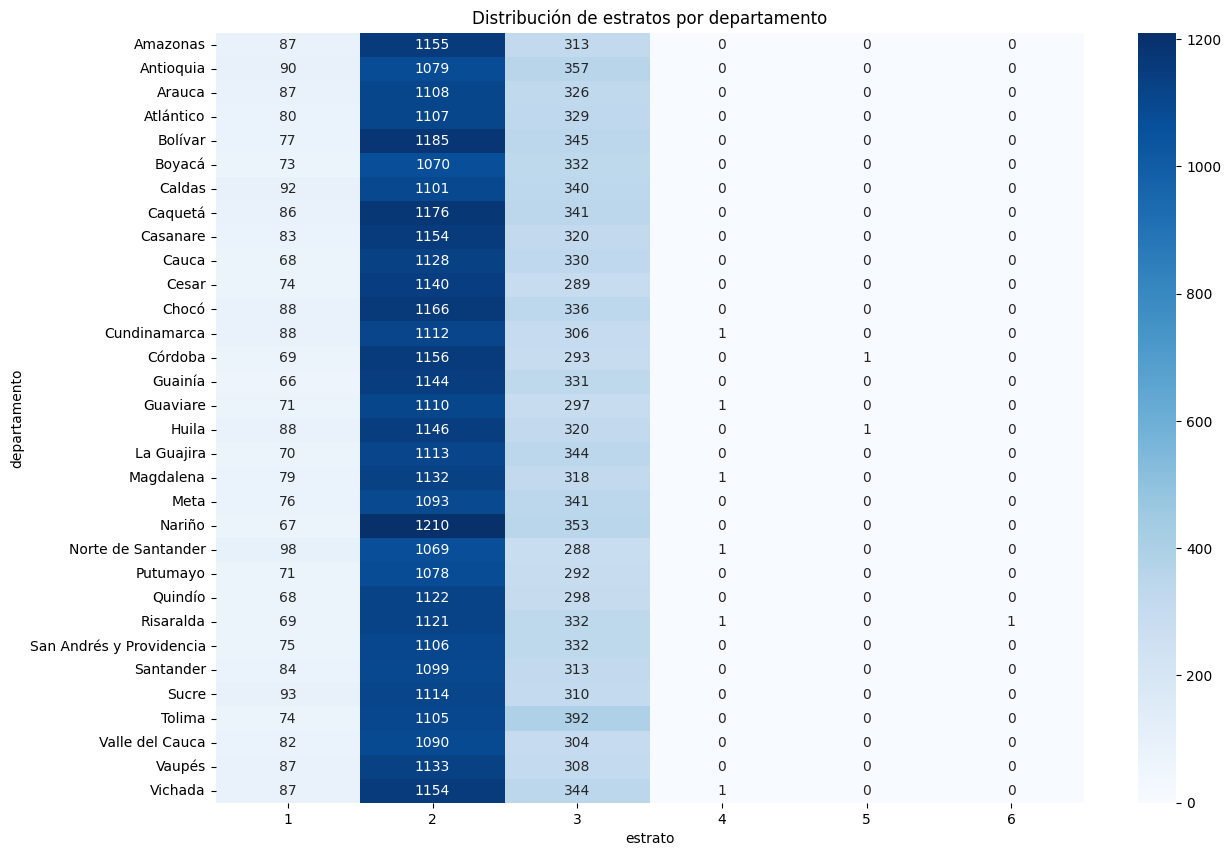

In [5]:

# Heatmap de distribución de estratos

plt.figure(figsize=(14,10))

sns.heatmap(
    tabla_estratos,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Distribución de estratos por departamento')

plt.show()


## Interpretación de la distribución territorial

La distribución de estratos evidencia diferencias territoriales entre departamentos, observándose variaciones en la concentración de registros asociados a estratos bajos, medios y altos.

Estos patrones permiten identificar comportamientos socioeconómicos diferenciados entre regiones del país y facilitan la evaluación territorial de la estratificación socioeconómica.

In [6]:

# Estrato promedio por departamento

estrato_promedio = df.groupby(
    'departamento'
)['estrato'].mean().sort_values()

estrato_promedio


departamento
Norte de Santander          2.131868
Sucre                       2.143045
Cesar                       2.143047
Vaupés                      2.144634
Amazonas                    2.145338
Cundinamarca                2.145985
Córdoba                     2.149440
Valle del Cauca             2.150407
Huila                       2.151125
Casanare                    2.152216
Santander                   2.153075
Putumayo                    2.153366
Guaviare                    2.154158
Quindío                     2.154570
Chocó                       2.155975
Arauca                      2.157133
Magdalena                   2.157516
Caquetá                     2.159077
Caldas                      2.161774
Vichada                     2.163304
Atlántico                   2.164248
Bolívar                     2.166770
San Andrés y Providencia    2.169861
Cauca                       2.171691
Guainía                     2.171966
Antioquia                   2.174967
Nariño                   

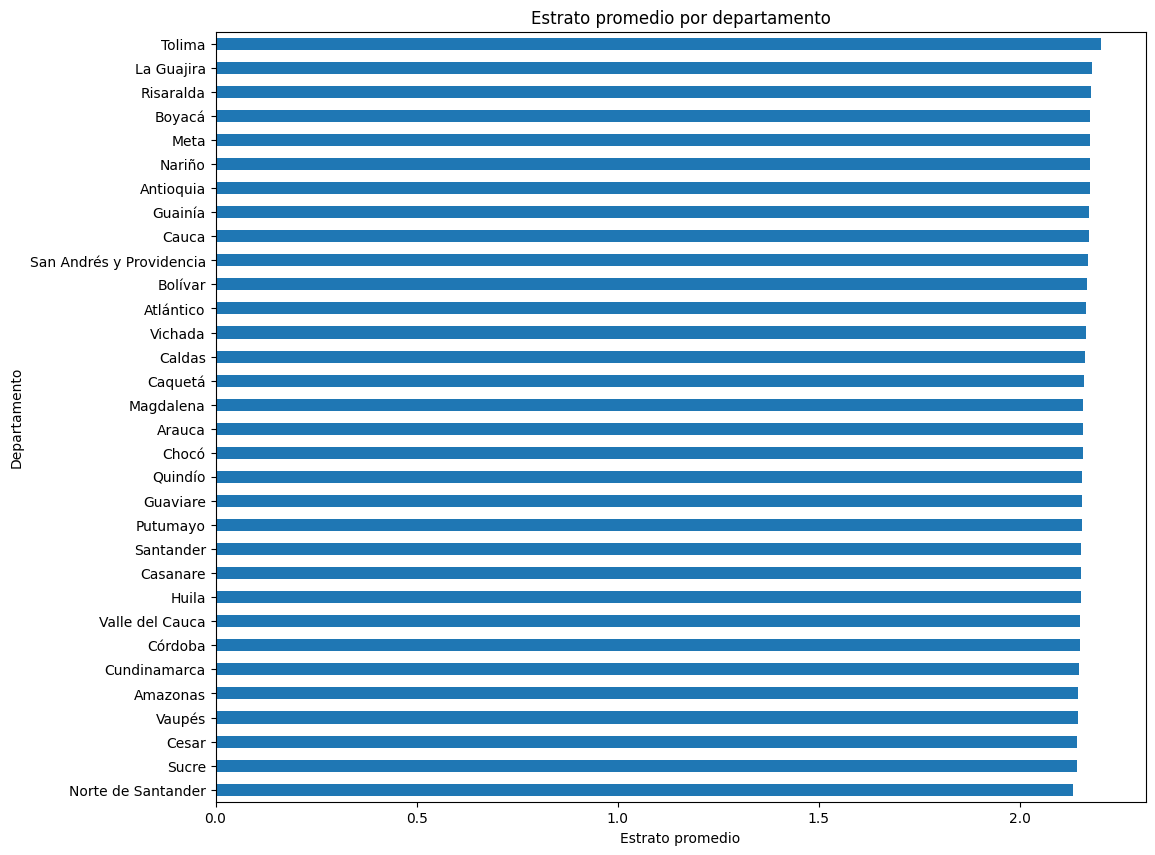

In [7]:

# Visualización estrato promedio

estrato_promedio.plot(
    kind='barh',
    figsize=(12,10)
)

plt.xlabel('Estrato promedio')
plt.ylabel('Departamento')
plt.title('Estrato promedio por departamento')

plt.show()


In [ ]:
# Departamentos con mayor estrato promedio

estrato_promedio.sort_values(
    ascending=False
).head(10)

In [ ]:
# Departamentos con menor estrato promedio

estrato_promedio.sort_values().head(10)


# 3.2 Comparación territorial entre departamentos

En esta sección se realiza una comparación territorial de indicadores asociados a:
- Área promedio
- Perímetro promedio
- Número promedio de pisos
- Estrato promedio


In [8]:

# Indicadores territoriales

comparacion_territorial = df.groupby(
    'departamento'
).agg({

    'area':'mean',
    'perimetro':'mean',
    'numero_pisos':'mean',
    'estrato':'mean'

}).round(2)

comparacion_territorial


,area,perimetro,numero_pisos,estrato
departamento,,,,
Amazonas,62.64,31.16,1.02,2.15
Antioquia,61.14,31.09,1.01,2.17
Arauca,70.79,32.38,1.02,2.16
Atlántico,62.05,31.51,1.02,2.16
Bolívar,60.86,30.79,1.03,2.17
Boyacá,62.86,31.35,1.03,2.18
Caldas,65.10,31.83,1.01,2.16
Caquetá,62.10,30.99,1.02,2.16
Casanare,63.54,31.68,1.02,2.15


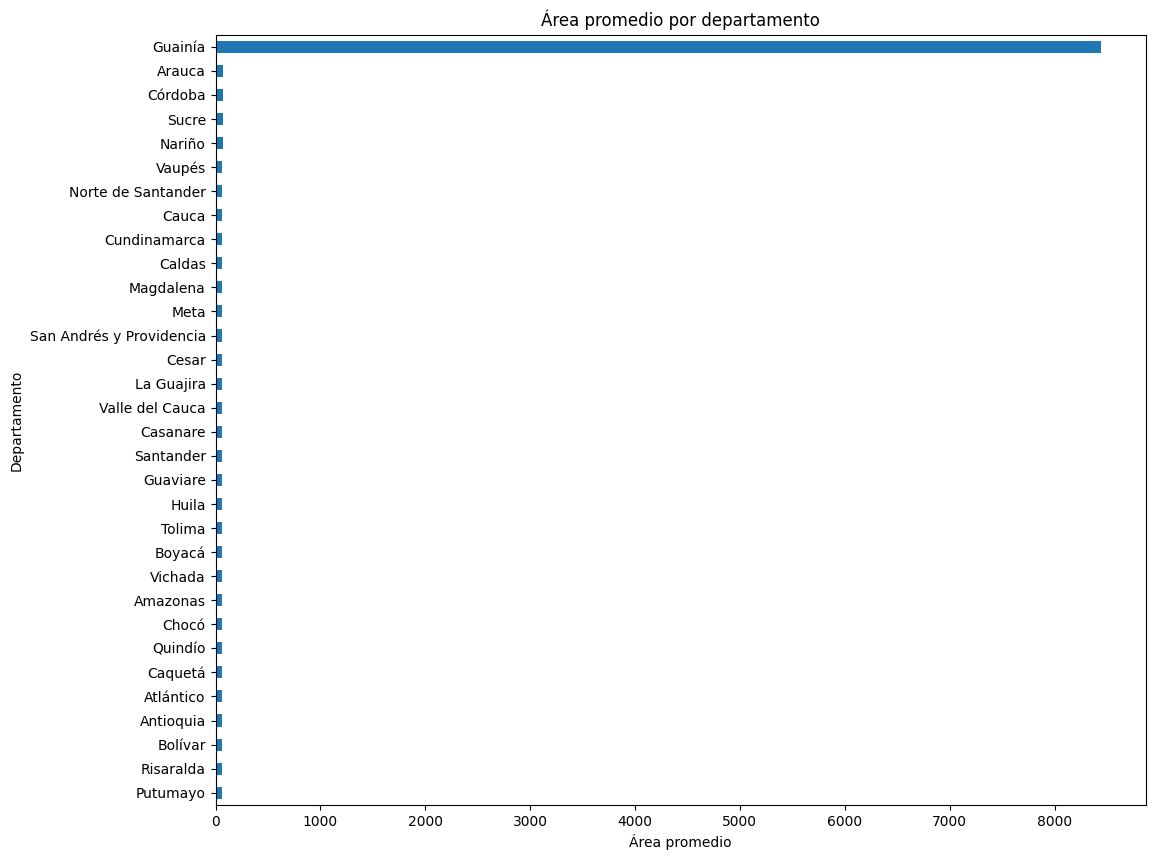

In [9]:

# Comparación de área promedio

comparacion_territorial['area'].sort_values().plot(
    kind='barh',
    figsize=(12,10)
)

plt.xlabel('Área promedio')
plt.ylabel('Departamento')
plt.title('Área promedio por departamento')

plt.show()


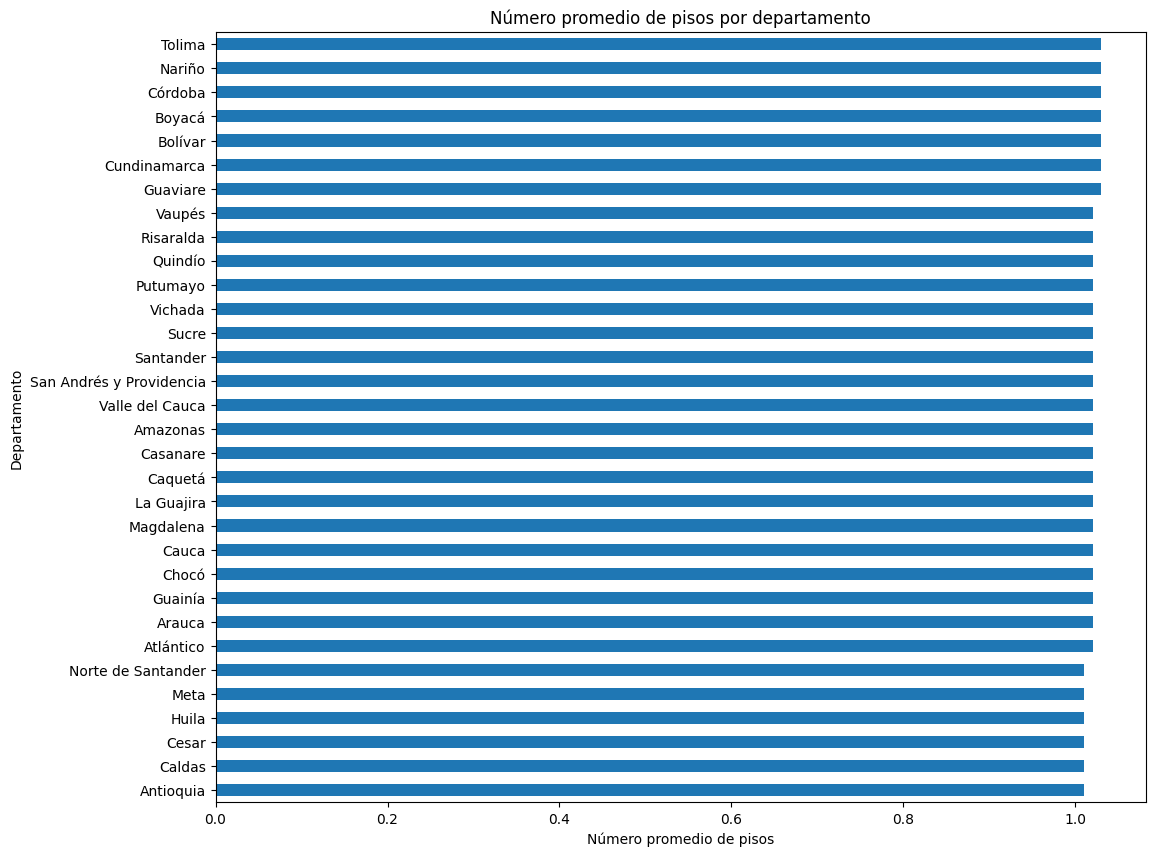

In [10]:

# Comparación de número de pisos

comparacion_territorial['numero_pisos'].sort_values().plot(
    kind='barh',
    figsize=(12,10)
)

plt.xlabel('Número promedio de pisos')
plt.ylabel('Departamento')
plt.title('Número promedio de pisos por departamento')

plt.show()



# 3.3 Identificación de diferencias relevantes en los estratos bajos

Se analizan los estratos bajos (1 y 2) para identificar diferencias territoriales relevantes entre departamentos.


In [11]:

# Filtrado de estratos bajos

estratos_bajos = df[
    df['estrato'].isin([1,2])
]

estratos_bajos.head()


,departamento,codigo_departamento,numero_pisos,area,perimetro,tipo_dominio,tipo_construccion,estrato
9,Boyacá,15,1,101.378906,41.335912,PRIVADO,CONVENCIONAL,2
11,Sucre,70,1,62.023438,39.787249,PRIVADO,CONVENCIONAL,2
12,Córdoba,23,1,97.089355,39.711620,PRIVADO,CONVENCIONAL,2
13,Magdalena,47,1,114.057617,47.765536,PRIVADO,CONVENCIONAL,1
14,Caldas,17,2,167.483398,53.886042,PRIVADO,CONVENCIONAL,1


In [12]:

# Cantidad de registros de estratos bajos por departamento

estratos_bajos['departamento'].value_counts()


departamento
Nariño                      1277
Bolívar                     1262
Caquetá                     1262
Chocó                       1254
Amazonas                    1242
Vichada                     1241
Casanare                    1237
Huila                       1234
Córdoba                     1225
Vaupés                      1220
Cesar                       1214
Magdalena                   1211
Guainía                     1210
Sucre                       1207
Cundinamarca                1200
Cauca                       1196
Arauca                      1195
Caldas                      1193
Risaralda                   1190
Quindío                     1190
Atlántico                   1187
La Guajira                  1183
Santander                   1183
San Andrés y Providencia    1181
Guaviare                    1181
Tolima                      1179
Valle del Cauca             1172
Antioquia                   1169
Meta                        1169
Norte de Santander          11

In [13]:

# Porcentaje de estratos bajos por departamento

porcentaje_bajos = (
    estratos_bajos['departamento']
    .value_counts(normalize=True) * 100
)

porcentaje_bajos


departamento
Nariño                      3.314903
Bolívar                     3.275965
Caquetá                     3.275965
Chocó                       3.255198
Amazonas                    3.224048
Vichada                     3.221452
Casanare                    3.211069
Huila                       3.203281
Córdoba                     3.179918
Vaupés                      3.166939
Cesar                       3.151364
Magdalena                   3.143577
Guainía                     3.140981
Sucre                       3.133193
Cundinamarca                3.115022
Cauca                       3.104639
Arauca                      3.102043
Caldas                      3.096851
Risaralda                   3.089064
Quindío                     3.089064
Atlántico                   3.081276
La Guajira                  3.070893
Santander                   3.070893
San Andrés y Providencia    3.065701
Guaviare                    3.065701
Tolima                      3.060509
Valle del Cauca          

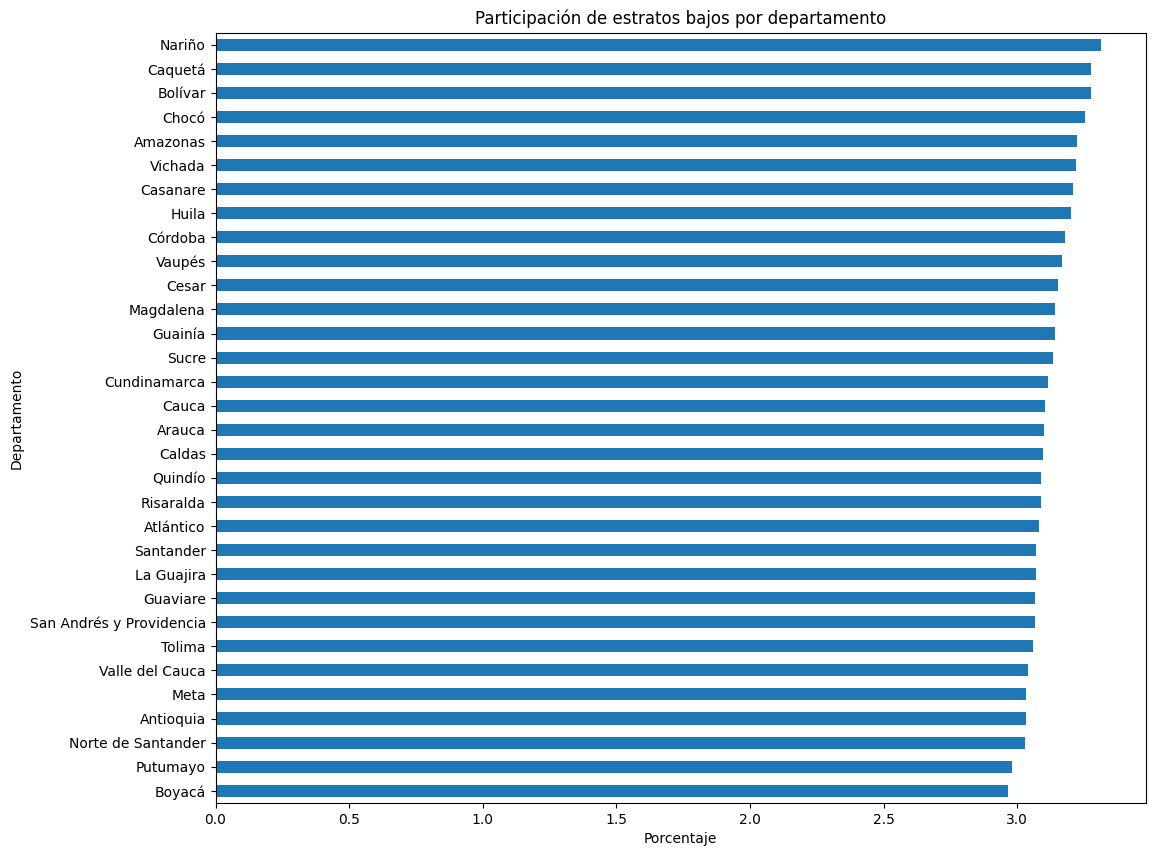

In [14]:

# Visualización de estratos bajos

porcentaje_bajos.sort_values().plot(
    kind='barh',
    figsize=(12,10)
)

plt.xlabel('Porcentaje')
plt.ylabel('Departamento')
plt.title('Participación de estratos bajos por departamento')

plt.show()


## Interpretación de estratos bajos

La participación de estratos bajos en determinados departamentos evidencia diferencias socioeconómicas territoriales relevantes.

Los departamentos con mayor concentración de estratos 1 y 2 reflejan condiciones asociadas a menores niveles de infraestructura y desarrollo urbano en comparación con otros territorios.


# 3.4 Interpretación de indicadores y visualizaciones

Las visualizaciones y tablas descriptivas permiten interpretar patrones territoriales relacionados con la estratificación socioeconómica en Colombia.


In [15]:

# Matriz de correlación

correlacion = df[
    ['area', 'perimetro', 'numero_pisos', 'estrato']
].corr()

correlacion


,area,perimetro,numero_pisos,estrato
area,1.000000,0.989915,-0.026137,-0.001508
perimetro,0.989915,1.000000,-0.002484,-0.002995
numero_pisos,-0.026137,-0.002484,1.000000,0.003736
estrato,-0.001508,-0.002995,0.003736,1.000000


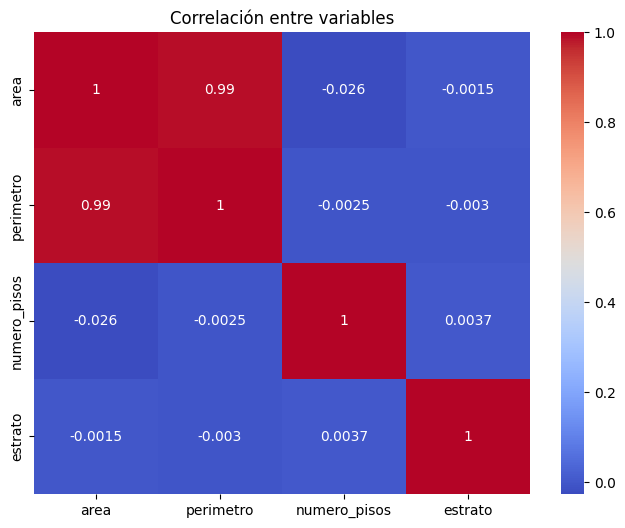

In [16]:

# Heatmap de correlación

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación entre variables')

plt.show()


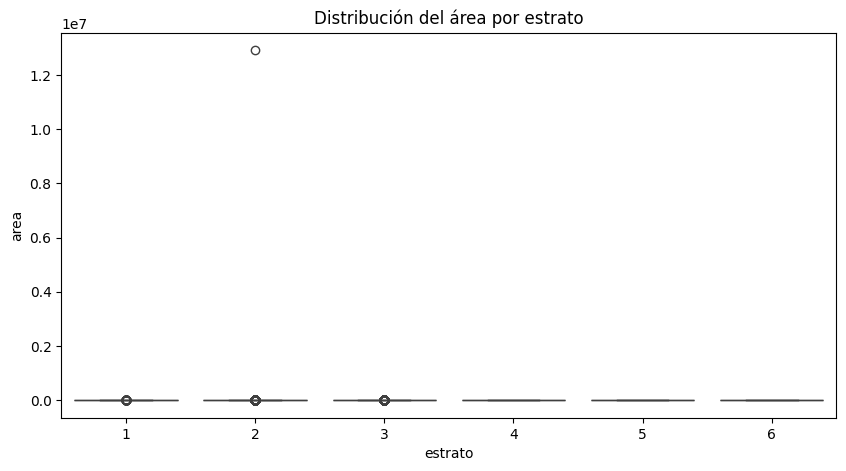

In [17]:

# Boxplot área por estrato

plt.figure(figsize=(10,5))

sns.boxplot(
    x='estrato',
    y='area',
    data=df
)

plt.title('Distribución del área por estrato')

plt.show()


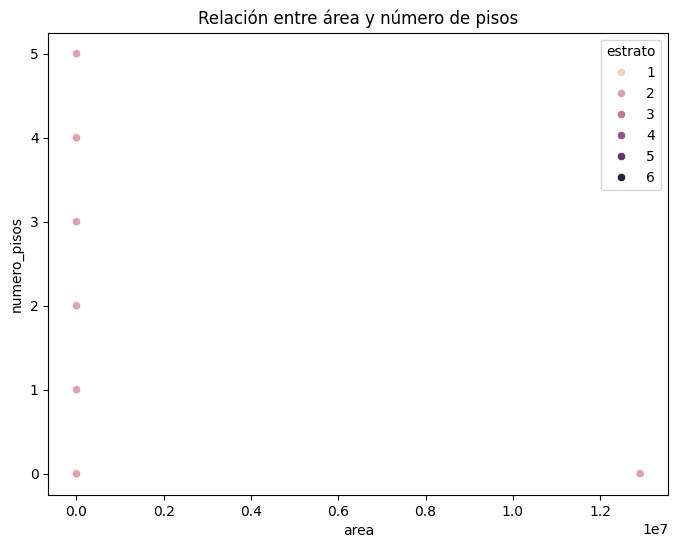

In [18]:

# Scatterplot área vs pisos

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='area',
    y='numero_pisos',
    hue='estrato'
)

plt.title('Relación entre área y número de pisos')

plt.show()


## Evaluación de variables físicas

Las variables físicas como área, perímetro y número de pisos presentan comportamientos diferenciados según el estrato socioeconómico.

En términos generales, los registros asociados a estratos más altos tienden a presentar mayores dimensiones físicas y características estructurales diferentes respecto a los estratos bajos.


# 3.5 Conclusiones y recomendaciones derivadas del análisis

Las conclusiones obtenidas permiten identificar patrones territoriales y diferencias socioeconómicas relevantes en Colombia.


# Hallazgos relevantes del análisis

- Se identificaron diferencias territoriales significativas en la distribución de estratos socioeconómicos entre departamentos de Colombia.

- Los estratos bajos presentan mayor concentración en determinados territorios del país.

- Las variables físicas muestran relación con el comportamiento de los estratos socioeconómicos.

- Los indicadores descriptivos permitieron identificar patrones territoriales relevantes asociados a condiciones socioeconómicas.

- La evaluación territorial facilitó la interpretación comparativa de los departamentos analizados.


# Conclusiones

- La distribución de estratos socioeconómicos presenta diferencias significativas entre los departamentos de Colombia.

- Los departamentos con mayores áreas promedio tienden a presentar estratos promedio más altos.

- Los estratos bajos presentan una participación importante en varios departamentos del país.

- Las variables físicas como área, perímetro y número de pisos muestran relación con el comportamiento de los estratos socioeconómicos.

- El análisis descriptivo territorial permitió identificar patrones regionales asociados a la estratificación socioeconómica.

- La fase Assess permitió evaluar la utilidad del modelo descriptivo territorial para interpretar patrones de estratificación socioeconómica en Colombia.

- La interpretación de indicadores y visualizaciones permitió identificar diferencias regionales relevantes entre departamentos del país.

# Recomendaciones

- Implementar análisis geográficos complementarios para profundizar en las diferencias territoriales.

- Incorporar variables socioeconómicas adicionales como ingresos, acceso a servicios y densidad poblacional.

- Fortalecer la actualización y calidad de los datos utilizados en futuros análisis.

- Utilizar dashboards interactivos para apoyar la toma de decisiones y el análisis territorial.


# Reflexión final del proceso analítico

La aplicación de la metodología SEMMA permitió desarrollar un proceso estructurado de selección, exploración, transformación, modelado y evaluación de datos asociados a la estratificación socioeconómica en Colombia.

El análisis descriptivo territorial facilitó la identificación de patrones regionales relevantes y permitió transformar datos originales en información útil para la interpretación socioeconómica y territorial.